# infra-jepa: JEPA Anomaly Detection on Real Microservice Data

**Dataset**: Alibaba Microservice Trace 2022  
**Architecture**: GraphSAGE Encoder + MLP Predictor + Surprise Scorer  
**Inspired by**: LeWorldModel (LeCun et al., 2026) — JEPA + SIGReg

This notebook downloads real Alibaba production microservice traces, builds graph snapshots, trains a JEPA world model, and surfaces anomalies as high-surprise transitions.


In [1]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


PyTorch: 2.10.0+cpu
CUDA available: False


In [2]:
!pip install -q torch-geometric scikit-learn matplotlib seaborn tqdm
print("Done.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.6 MB/s eta 0:00:00
Done.


## 2. Download Real Alibaba Data

In [3]:
import os
os.makedirs("data/MSMetrics", exist_ok=True)
os.makedirs("data/CallGraph", exist_ok=True)

base = "https://aliopentrace.oss-cn-beijing.aliyuncs.com/v2022MicroservicesTraces"
print("Downloading MSMetrics (~355MB)...")
!wget -q --show-progress -O data/MSMetrics/MSMetrics_0.tar.gz "$base/MSMetricsUpdate/MSMetricsUpdate_0.tar.gz"
print("Downloading CallGraph (~212MB)...")
!wget -q --show-progress -O data/CallGraph/CallGraph_0.tar.gz "$base/CallGraph/CallGraph_0.tar.gz"
print("Downloads complete.")


data/MSMetrics/MSMe 100%[===================>] 355.39M  15.8MB/s    in 25s     
data/CallGraph/Call 100%[===================>] 212.73M  17.9MB/s    in 13s     
Downloads complete.


In [4]:
!tar -xzf data/MSMetrics/MSMetrics_0.tar.gz -C data/MSMetrics/
!tar -xzf data/CallGraph/CallGraph_0.tar.gz -C data/CallGraph/
import glob
ms_files = glob.glob("data/MSMetrics/*.csv")
cg_files = glob.glob("data/CallGraph/*.csv")
print("MSMetrics:", ms_files)
print("CallGraph:", cg_files)


MSMetrics: ['data/MSMetrics/MSMetricsUpdate_0.csv']
CallGraph: ['data/CallGraph/CallGraph_0.csv']


## 3. Load and Explore

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Loading 500k rows each...")
cg_raw = pd.read_csv(cg_files[0], nrows=500_000, on_bad_lines='skip')
ms_raw = pd.read_csv(ms_files[0], nrows=500_000, on_bad_lines='skip')
print(f"CallGraph: {cg_raw.shape}")
print(f"MSMetrics: {ms_raw.shape}")
print("CallGraph cols:", list(cg_raw.columns))
print("MSMetrics cols:", list(ms_raw.columns))

Loading 500k rows each...
CallGraph: (500000, 11)
MSMetrics: (500000, 6)
CallGraph cols: ['timestamp', 'traceid', 'service', 'rpc_id', 'rpctype', 'um', 'uminstanceid', 'interface', 'dm', 'dminstanceid', 'rt']
MSMetrics cols: ['timestamp', 'msname', 'msinstanceid', 'nodeid', 'cpu_utilization', 'memory_utilization']


In [9]:
print(f"Unique microservices (MSMetrics): {ms_raw.msname.nunique()}")
print(f"Unique upstream services (CallGraph): {cg_raw.um.nunique()}")
print(f"Unique downstream services (CallGraph): {cg_raw.dm.nunique()}")
ts_min = cg_raw.timestamp.min()
ts_max = cg_raw.timestamp.max()
print(f"Timestamp range: {ts_min} to {ts_max}")
print(f"Duration: {(ts_max - ts_min) / 60000:.1f} minutes")

Unique microservices (MSMetrics): 11581
Unique upstream services (CallGraph): 3991
Unique downstream services (CallGraph): 6900
Timestamp range: 1 to 179999
Duration: 3.0 minutes


## 4. Preprocess

In [18]:
cg = cg_raw.rename(columns={"um": "src_ms", "dm": "dst_ms", "rt": "latency"})
cg["timestamp"] = pd.to_datetime(cg["timestamp"], unit="s", utc=True)
cg = cg[["timestamp", "src_ms", "dst_ms", "latency"]].dropna()

ms = ms_raw.rename(columns={"cpu_utilization": "cpu_use", "memory_utilization": "mem_use"})
ms["timestamp"] = pd.to_datetime(ms["timestamp"], unit="s", utc=True)
ms = ms[["timestamp", "msname", "cpu_use", "mem_use"]].dropna()

print(f"CallGraph rows: {len(cg):,}")
print(f"MSMetrics rows: {len(ms):,}")
print(f"CallGraph time range: {cg.timestamp.min()} to {cg.timestamp.max()}")
print(f"MSMetrics time range: {ms.timestamp.min()} to {ms.timestamp.max()}")

CallGraph rows: 489,419
MSMetrics rows: 500,000
CallGraph time range: 1970-01-01 00:00:01+00:00 to 1970-01-03 01:59:59+00:00
MSMetrics time range: 1970-01-01 00:00:00+00:00 to 1970-01-21 03:20:00+00:00


## 5. Build Graph Snapshots

In [19]:
import torch
from torch_geometric.data import Data

def build_snapshots(call_graph, resource, window_minutes=5, min_edges=1):
    freq = f"{window_minutes}min"
    cg = call_graph.copy()
    res = resource.copy()
    cg["window"] = cg["timestamp"].dt.floor(freq)
    res["window"] = res["timestamp"].dt.floor(freq)
    all_windows = sorted(set(cg["window"].unique()) | set(res["window"].unique()))
    snapshots = []
    for window_start in all_windows:
        cg_win = cg[cg["window"] == window_start]
        res_win = res[res["window"] == window_start]
        if len(cg_win) < min_edges:
            continue
        nodes = sorted(set(cg_win["src_ms"]) | set(cg_win["dst_ms"]) | set(res_win["msname"]))
        node_to_idx = {n: i for i, n in enumerate(nodes)}
        n_nodes = len(nodes)
        node_feats = np.zeros((n_nodes, 2), dtype=np.float32)
        if not res_win.empty:
            agg = res_win.groupby("msname")[["cpu_use", "mem_use"]].mean()
            for svc, row in agg.iterrows():
                if svc in node_to_idx:
                    node_feats[node_to_idx[svc]] = [row["cpu_use"], row["mem_use"]]
        edge_agg = (
            cg_win.groupby(["src_ms", "dst_ms"])["latency"]
            .agg(mean_latency="mean", call_count="count")
            .reset_index()
        )
        src_idx = [node_to_idx[s] for s in edge_agg["src_ms"]]
        dst_idx = [node_to_idx[d] for d in edge_agg["dst_ms"]]
        data = Data(
            x=torch.tensor(node_feats),
            edge_index=torch.tensor([src_idx, dst_idx], dtype=torch.long),
            edge_attr=torch.tensor(edge_agg[["mean_latency", "call_count"]].values.astype(np.float32))
        )
        data.window_start = window_start
        data.node_names = nodes
        snapshots.append(data)
    return snapshots

def normalize_snapshots(snapshots):
    all_x = torch.cat([s.x for s in snapshots], dim=0)
    x_mean, x_std = all_x.mean(0), all_x.std(0).clamp(min=1e-8)
    all_ea = torch.cat([s.edge_attr for s in snapshots], dim=0)
    ea_mean, ea_std = all_ea.mean(0), all_ea.std(0).clamp(min=1e-8)
    for s in snapshots:
        s.x = (s.x - x_mean) / x_std
        s.edge_attr = (s.edge_attr - ea_mean) / ea_std
    return snapshots

print("Building snapshots...")
snapshots = build_snapshots(cg, ms, window_minutes=5)
print(f"Built {len(snapshots)} snapshots")
if snapshots:
    s = snapshots[0]
    print(f"First: {s.x.shape[0]} nodes, {s.edge_index.shape[1]} edges, window={s.window_start}")
snapshots = normalize_snapshots(snapshots)
print("Normalized.")

Building snapshots...
Built 600 snapshots
First: 6476 nodes, 343 edges, window=1970-01-01 00:00:00+00:00
Normalized.


## 6. Define JEPA Model

In [20]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, global_mean_pool

class GraphEncoder(nn.Module):
    def __init__(self, node_feat_dim=2, hidden_dim=64, embed_dim=32, num_layers=2):
        super().__init__()
        dims = [node_feat_dim] + [hidden_dim] * (num_layers - 1) + [embed_dim]
        self.layers = nn.ModuleList([SAGEConv(dims[i], dims[i+1]) for i in range(num_layers)])
    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        for i, layer in enumerate(self.layers):
            x = layer(x, edge_index)
            if i < len(self.layers) - 1:
                x = F.relu(x)
        return global_mean_pool(x, batch)

class MLPPredictor(nn.Module):
    def __init__(self, embed_dim=32, hidden_dim=64, num_layers=2):
        super().__init__()
        dims = [embed_dim] + [hidden_dim] * (num_layers - 1) + [embed_dim]
        self.layers = nn.ModuleList([nn.Linear(dims[i], dims[i+1]) for i in range(num_layers)])
    def forward(self, z):
        out = z
        for i, layer in enumerate(self.layers):
            out = layer(out)
            if i < len(self.layers) - 1:
                out = F.relu(out)
        return out + z

class JEPAModel(nn.Module):
    def __init__(self, node_feat_dim=2, hidden_dim=64, embed_dim=32, encoder_layers=2):
        super().__init__()
        self.encoder = GraphEncoder(node_feat_dim, hidden_dim, embed_dim, encoder_layers)
        self.predictor = MLPPredictor(embed_dim, hidden_dim)
    def encode(self, snap):
        return self.encoder(snap)
    def predict(self, z):
        return self.predictor(z)
    def forward(self, s_t, s_t1):
        z_t = self.encode(s_t)
        z_t1 = self.encode(s_t1)
        return z_t, z_t1, self.predict(z_t)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = JEPAModel().to(device)
print(f"Model on: {device}")
print(model)

Model on: cpu
JEPAModel(
  (encoder): GraphEncoder(
    (layers): ModuleList(
      (0): SAGEConv(2, 64, aggr=mean)
      (1): SAGEConv(64, 32, aggr=mean)
    )
  )
  (predictor): MLPPredictor(
    (layers): ModuleList(
      (0): Linear(in_features=32, out_features=64, bias=True)
      (1): Linear(in_features=64, out_features=32, bias=True)
    )
  )
)


## 7. Loss Functions

In [21]:
def sigreg_loss(z):
    B, D = z.shape
    if B < 2:
        return z.new_zeros(1).squeeze()
    z_c = z - z.mean(0, keepdim=True)
    cov = (z_c.T @ z_c) / (B - 1)
    diff = cov - torch.eye(D, device=z.device)
    return (diff ** 2).sum()

def jepa_loss(z_pred, z_target, z_context, lam=0.04):
    pred_l = F.mse_loss(z_pred, z_target)
    reg_l = sigreg_loss(torch.cat([z_context, z_target], dim=0))
    return pred_l + lam * reg_l, pred_l, reg_l

print("Loss functions ready.")

Loss functions ready.


## 8. Train

In [22]:
import torch.optim as optim

EPOCHS = 100
optimizer = optim.Adam(model.parameters(), lr=1e-3)
history = []

model.train()
for epoch in range(1, EPOCHS + 1):
    total_loss = pred_loss = reg_loss = 0.0
    n = len(snapshots) - 1
    for i in range(n):
        s_t = snapshots[i].to(device)
        s_t1 = snapshots[i+1].to(device)
        optimizer.zero_grad()
        z_t, z_t1, z_pred = model(s_t, s_t1)
        loss, pl, rl = jepa_loss(z_pred, z_t1, z_t)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pred_loss += pl.item()
        reg_loss += rl.item()
    m = {"epoch": epoch, "total": total_loss/n, "pred": pred_loss/n, "reg": reg_loss/n}
    history.append(m)
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | total={m['total']:.4f}  pred={m['pred']:.4f}  reg={m['reg']:.4f}")

torch.save(model.state_dict(), "jepa_real.pt")
print("Model saved.")

Epoch   1 | total=1.2814  pred=0.0011  reg=32.0079
Epoch  10 | total=1.2799  pred=0.0002  reg=31.9927
Epoch  20 | total=1.2756  pred=0.0065  reg=31.7288
Epoch  30 | total=1.2753  pred=0.0065  reg=31.7211
Epoch  40 | total=1.2753  pred=0.0066  reg=31.7176
Epoch  50 | total=1.2752  pred=0.0067  reg=31.7108
Epoch  60 | total=1.2745  pred=0.0073  reg=31.6802
Epoch  70 | total=1.2738  pred=0.0084  reg=31.6350
Epoch  80 | total=1.2735  pred=0.0088  reg=31.6169
Epoch  90 | total=1.2734  pred=0.0092  reg=31.6051
Epoch 100 | total=1.2733  pred=0.0092  reg=31.6035
Model saved.


## 9. Training Loss Plot

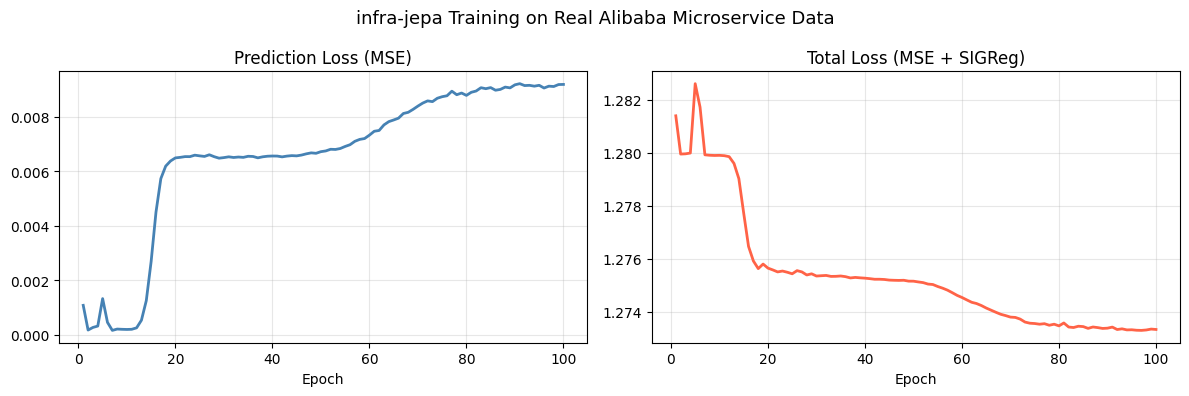

In [23]:
epochs = [h["epoch"] for h in history]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs, [h["pred"] for h in history], color="steelblue", lw=2)
ax1.set_title("Prediction Loss (MSE)")
ax1.set_xlabel("Epoch")
ax1.grid(alpha=0.3)
ax2.plot(epochs, [h["total"] for h in history], color="tomato", lw=2)
ax2.set_title("Total Loss (MSE + SIGReg)")
ax2.set_xlabel("Epoch")
ax2.grid(alpha=0.3)
plt.suptitle("infra-jepa Training on Real Alibaba Microservice Data", fontsize=13)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()

## 10. Anomaly Scoring

In [29]:
model.eval()
scores = []
with torch.no_grad():
    for i in range(len(snapshots) - 1):
        s_t = snapshots[i].to(device)
        s_t1 = snapshots[i+1].to(device)
        _, z_t1, z_pred = model(s_t, s_t1)
        scores.append(float(torch.norm(z_pred - z_t1, p=2).item()))

scores = np.array(scores)
threshold = scores.mean() + 3 * scores.std()
anomalies = np.where(scores > threshold)[0]

print(f"Transitions scored: {len(scores)}")
print(f"Threshold (mean+3sigma): {threshold:.4f}")
print(f"Anomalies detected: {len(anomalies)}")
for idx in anomalies:
    print(f"  Transition {idx}: window={snapshots[idx].window_start}  score={scores[idx]:.4f}")

Transitions scored: 599
Threshold (mean+3sigma): 1.2285
Anomalies detected: 5
  Transition 140: window=1970-01-01 11:40:00+00:00  score=1.2570
  Transition 141: window=1970-01-01 11:45:00+00:00  score=1.3017
  Transition 406: window=1970-01-02 09:50:00+00:00  score=1.2539
  Transition 523: window=1970-01-02 19:35:00+00:00  score=1.2344
  Transition 540: window=1970-01-02 21:00:00+00:00  score=1.3653


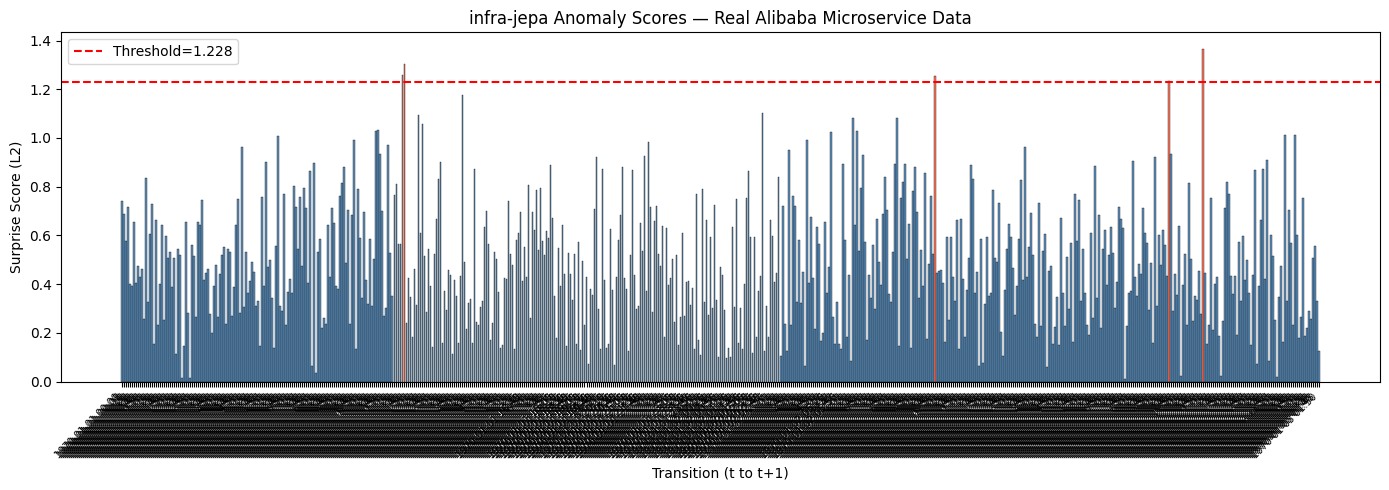

In [25]:
colors = ["tomato" if s > threshold else "steelblue" for s in scores]
labels = [str(snapshots[i].window_start)[:16] for i in range(len(scores))]
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(scores)), scores, color=colors, alpha=0.85, edgecolor="k", lw=0.3)
ax.axhline(threshold, color="red", linestyle="--", lw=1.5, label=f"Threshold={threshold:.3f}")
ax.set_xticks(range(len(scores)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
ax.set_xlabel("Transition (t to t+1)")
ax.set_ylabel("Surprise Score (L2)")
ax.set_title("infra-jepa Anomaly Scores — Real Alibaba Microservice Data")
ax.legend()
plt.tight_layout()
plt.savefig("anomaly_scores.png", dpi=150)
plt.show()

## 11. t-SNE Latent Space

Embedding matrix: (600, 32)


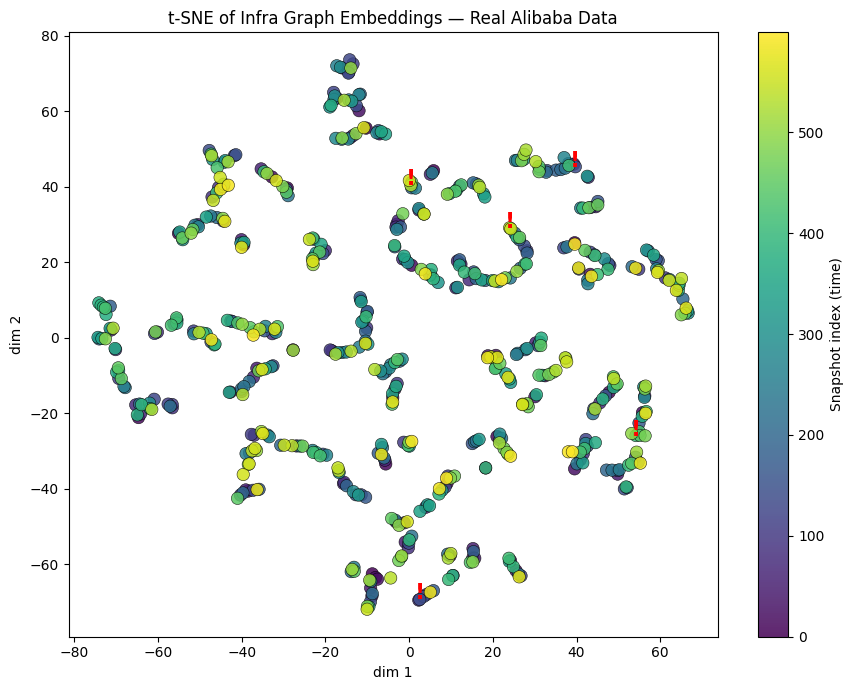

In [26]:
from sklearn.manifold import TSNE

model.eval()
embeddings = []
with torch.no_grad():
    for snap in snapshots:
        z = model.encode(snap.to(device))
        embeddings.append(z.cpu())

emb = torch.cat(embeddings, dim=0).numpy()
print(f"Embedding matrix: {emb.shape}")

perplexity = min(5.0, len(snapshots) - 1)
coords = TSNE(n_components=2, perplexity=perplexity, random_state=42).fit_transform(emb)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(coords[:, 0], coords[:, 1],
    c=np.arange(len(snapshots)), cmap="viridis",
    s=80, alpha=0.85, edgecolors="k", lw=0.4)
plt.colorbar(sc, ax=ax, label="Snapshot index (time)")
for idx in anomalies:
    ax.annotate("!", (coords[idx, 0], coords[idx, 1]),
        fontsize=16, color="red", fontweight="bold", ha="center")
ax.set_title("t-SNE of Infra Graph Embeddings — Real Alibaba Data")
ax.set_xlabel("dim 1")
ax.set_ylabel("dim 2")
plt.tight_layout()
plt.savefig("tsne.png", dpi=150)
plt.show()

In [27]:
## 12. Summary

In [28]:
print("=" * 50)
print("infra-jepa Run Summary")
print("=" * 50)
print(f"Dataset:         Alibaba Microservice Trace 2022")
print(f"Snapshots:       {len(snapshots)} x 5-min windows")
print(f"Avg nodes/snap:  {int(np.mean([s.x.shape[0] for s in snapshots]))}")
print(f"Avg edges/snap:  {int(np.mean([s.edge_index.shape[1] for s in snapshots]))}")
print(f"Final pred loss: {history[-1][chr(39)]pred[chr(39)]:.4f}")
        print(f"Final pred loss: {history[-1]['pred']:.4f}")
print(f"Threshold:       {threshold:.4f} (mean + 3 sigma)")
print("=" * 50)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1342703280.py, line 8)